**Housing Price Prediction**

In [79]:
#Before starting anything first we need to import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

In [80]:
#Load the dataset from the library
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


**Seems interesting our lovely friend (PRICE) is not the data frame. I think we to need to satisfy him for working with us.**

In [81]:
df['price'] = data.target

In [82]:
#Look at the total number of friends that participate
Features = df.columns
print("Total number of features: ", len(Features))
print("=" * 40)
for i in Features:
     print(i)

Total number of features:  9
MedInc
HouseAge
AveRooms
AveBedrms
Population
AveOccup
Latitude
Longitude
price


In [83]:
#Now let's check the number of rows and columns
print("Number of rows: ", df.shape[0])
print("Number of columns: ", df.shape[1])
print("=" * 40)

#Now let's check the data types
print(df.dtypes)
print("=" * 40)

Number of rows:  20640
Number of columns:  9
MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
price         float64
dtype: object


**Great our all friends are numerical like they didn't like categorical data.**

In [84]:
#Now let see if there is any missing friends
print("Number of missing values: ", df.isnull().sum().sum())
print("=" * 40)
print(df.isnull().sum())

Number of missing values:  0
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
price         0
dtype: int64


**That's very appreciable, that our all friends are ready to participate.**

In [85]:
#Now let's check some random friends
df.sample(15)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
9821,2.6713,52.0,4.636364,1.064171,391.0,2.090909,36.62,-121.92,2.346
16584,3.5096,33.0,4.921260,0.952756,970.0,2.545932,37.74,-121.44,1.417
17916,3.2048,33.0,4.229068,1.017378,1469.0,2.320695,37.36,-121.99,2.618
2354,4.0993,5.0,5.432432,0.989605,1490.0,3.097713,36.79,-119.69,0.830
15807,3.9079,52.0,4.817352,1.036530,816.0,1.863014,37.76,-122.44,3.700
17418,3.0710,8.0,4.596296,1.085185,1427.0,2.642593,34.64,-120.47,1.204
12730,5.3243,29.0,6.237864,0.936893,460.0,2.233010,38.59,-121.35,2.657
9989,2.4726,15.0,5.180577,1.000759,3002.0,2.277693,39.15,-121.07,1.434
1633,2.4444,20.0,6.333333,0.866667,31.0,2.066667,37.88,-122.22,4.750
20031,2.2277,26.0,5.214797,1.038186,1108.0,2.644391,36.07,-119.04,0.780


In [86]:
#Check the statistical summary of the data
df.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


**Our main friend is price so we need to play with it.**

In [87]:
print("Statistical summary of price")
df['price'].describe().round(2)

Statistical summary of price


count    20640.00
mean         2.07
std          1.15
min          0.15
25%          1.20
50%          1.80
75%          2.65
max          5.00
Name: price, dtype: float64

In [88]:
#Now let's check in a different way
print("House Price Statistics ($100,000s mein):")
print(f"  Minimum : ${df['price'].min()*100:,.0f}k")
print(f"  Maximum : ${df['price'].max()*100:,.0f}k")
print(f"  Mean    : ${df['price'].mean()*100:,.0f}k")
print(f"  Median  : ${df['price'].median()*100:,.0f}k")
print(f"  Std Dev : ${df['price'].std()*100:,.0f}k")
print("=" * 40)
print(f"\nNote: $500k ceiling hai — bahut se expensive houses capped hain")

House Price Statistics ($100,000s mein):
  Minimum : $15k
  Maximum : $500k
  Mean    : $207k
  Median  : $180k
  Std Dev : $115k

Note: $500k ceiling hai — bahut se expensive houses capped hain


In [89]:
#Now check the skewness and kurtosis of price column
print("Skewness: ", df['price'].skew().round(2))
print("Kurtosis: ", df['price'].kurtosis().round(2))
print("=" * 40)

Skewness:  0.98
Kurtosis:  0.33


**Skewness:  0.9777632739098335, This means our data is skewed to the right**

**By using dist plot we can check the distribution of the price column.**

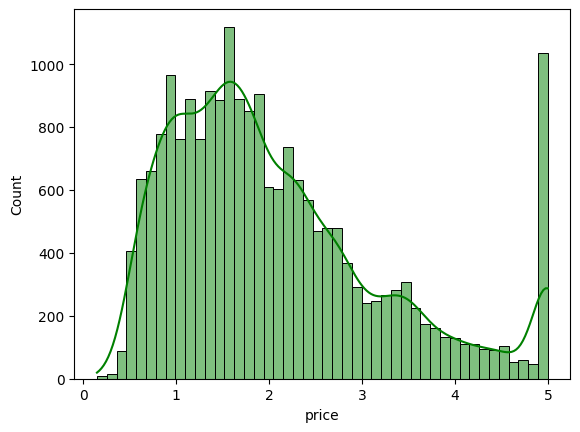

In [90]:
#Now check the distribution of price using dist plot
sns.histplot(df["price"], kde=True, color="green")
plt.show()

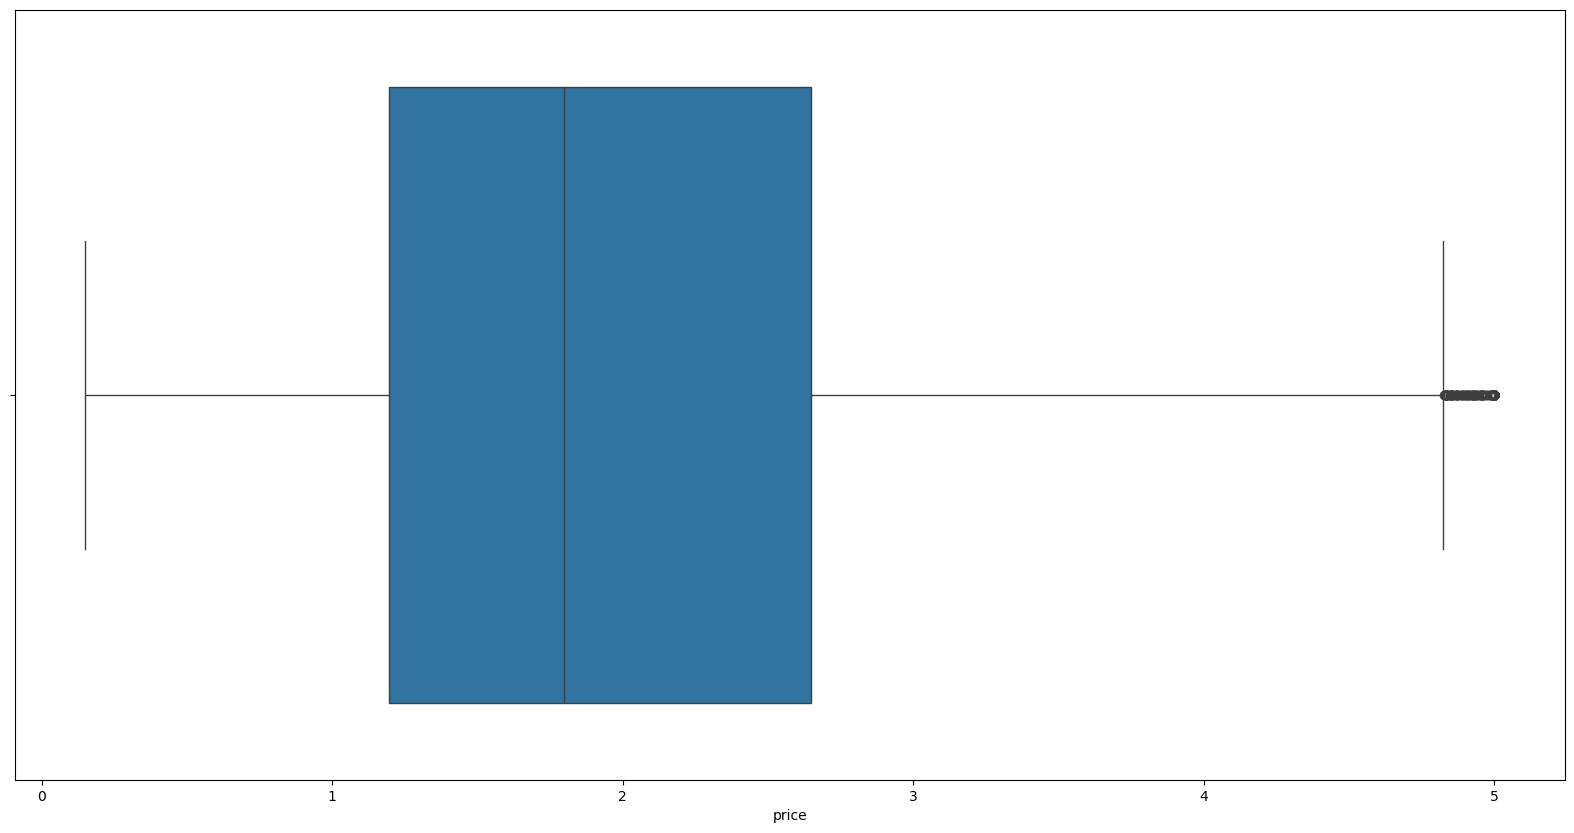

In [91]:
#now let's check the outliers using Box plot
fig = plt.figure(figsize=(20, 10))
sns.boxplot(data=df['price'], orient="h")
plt.show()

It seems that there are some outliers in our data

**The plot shows that in right side our some friends are very expensive.**

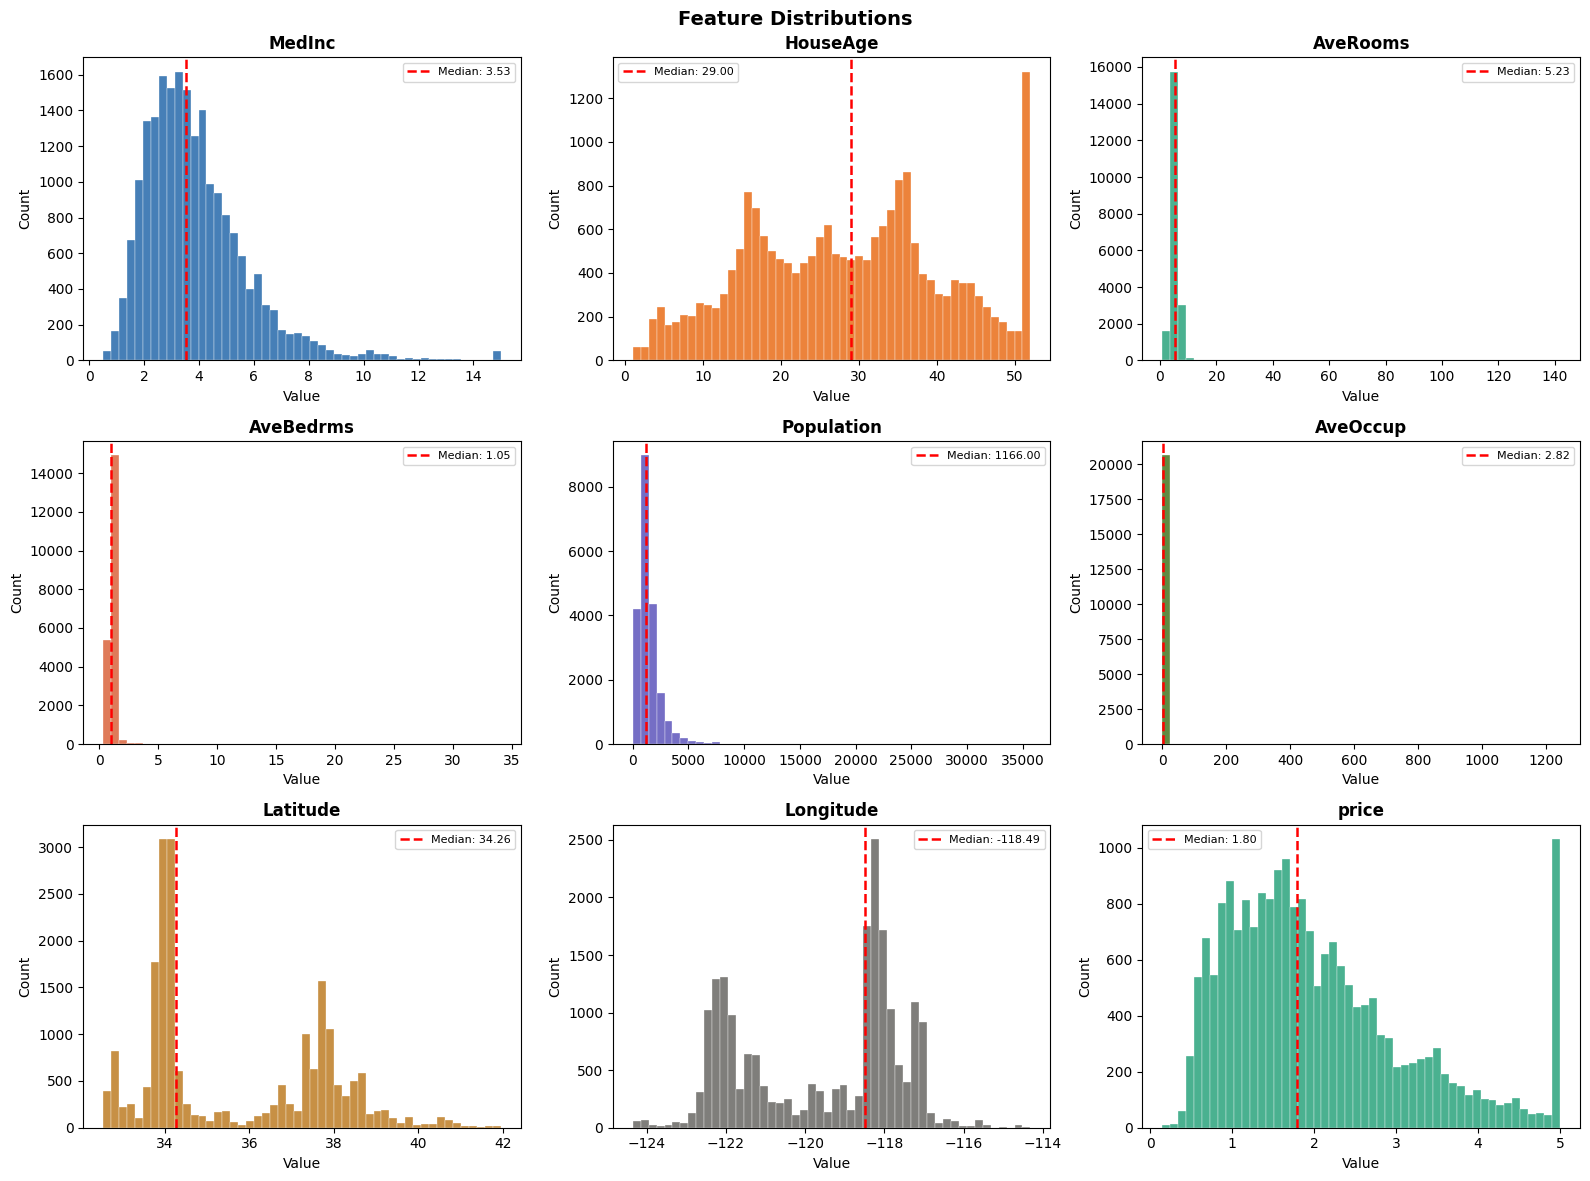

In [92]:
# %% ── CELL 7: Feature Distributions ───────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
 
colors = ['#185FA5','#E8640A','#1D9E75','#D85A30',
          '#534AB7','#3B6D11','#BA7517','#5F5E5A','#1D9E75']
 
for i, (col, clr) in enumerate(zip(df.columns, colors)):
    axes[i].hist(df[col], bins=50, color=clr,
                 alpha=0.8, edgecolor='white', linewidth=0.3)
    axes[i].axvline(df[col].median(), color='red',
                    linestyle='--', linewidth=1.8,
                    label=f'Median: {df[col].median():.2f}')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)
 
plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**- MedInc: right-skewed (Most people are low income)**

**- Population: right-skewed (outliers)**

**- PRICE: $500k pe cap dikh raha hai (flat right end)**

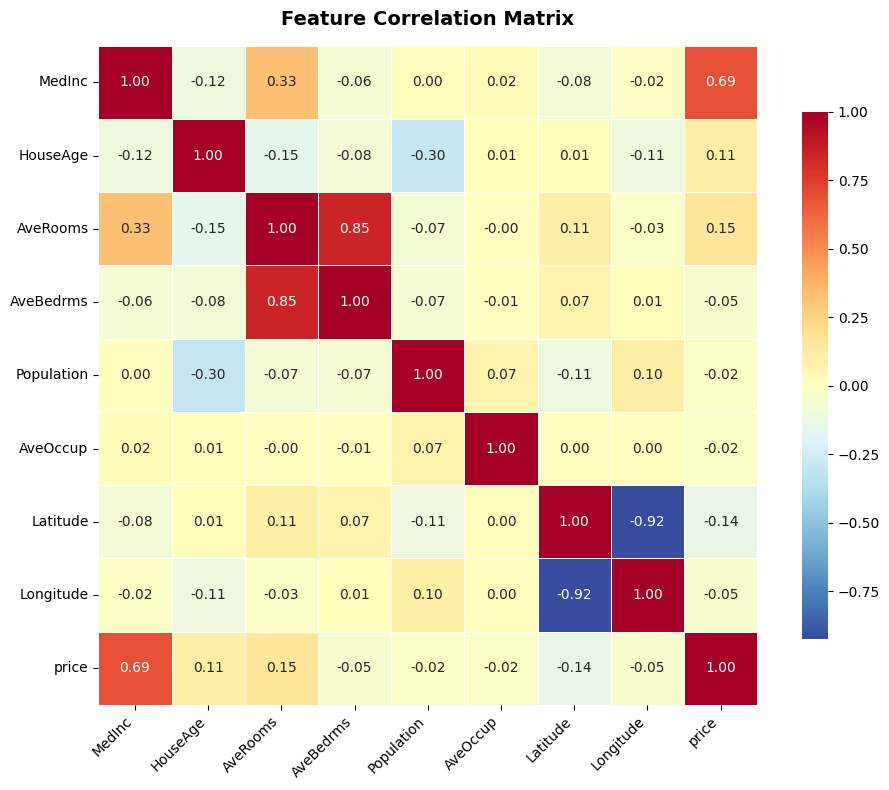

In [93]:
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(
    corr,
    annot=True,          # numbers dikhao
    fmt='.2f',           # 2 decimal places
    cmap='RdYlBu_r',     # red=negative, blue=positive
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**- MedInc aur PRICE ka strong positive correlation (blue)**

**- Latitude/Longitude ka apas mein correlation (location)**

In [94]:
#Now let's check the correlation of different features with price
print("Correlation of other features with price")
print("=" * 40)
df.corrwith(df['price']).sort_values(ascending=False)

Correlation of other features with price


price         1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
dtype: float64

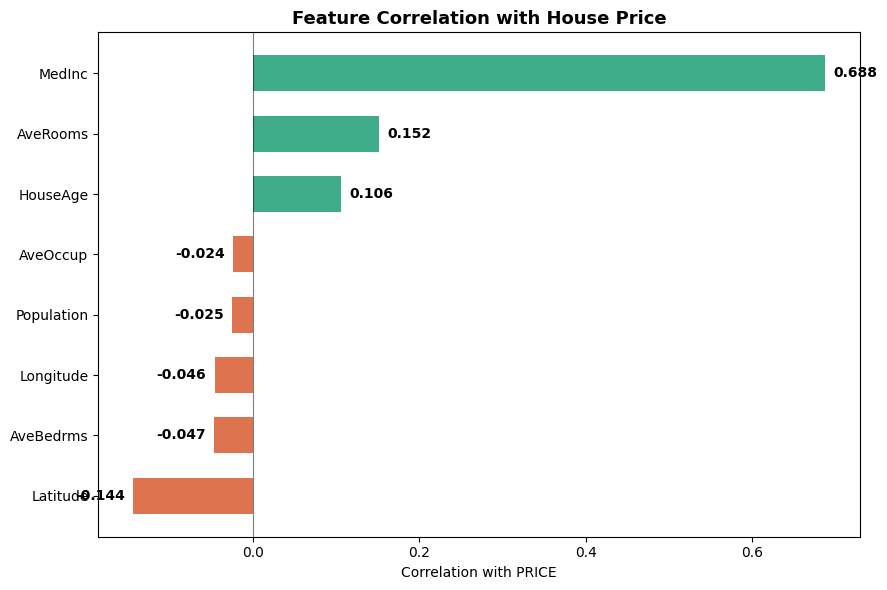

In [95]:
#Now let's check the correlation of different features with price by using plot
price_corr = df.corr()['price'].drop('price').sort_values()
 
plt.figure(figsize=(9, 6))
colors = ['#D85A30' if v < 0 else '#1D9E75' for v in price_corr.values]
bars = plt.barh(price_corr.index, price_corr.values,
                color=colors, alpha=0.85, height=0.6)
plt.axvline(0, color='black', linewidth=0.8, alpha=0.5)
 
for bar, val in zip(bars, price_corr.values):
    plt.text(val + (0.01 if val >= 0 else -0.01),
             bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center',
             ha='left' if val >= 0 else 'right',
             fontsize=10, fontweight='bold')
 
plt.xlabel('Correlation with PRICE')
plt.title('Feature Correlation with House Price', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**MedInc (income) → STRONGEST positive (r ≈ 0.69)**

**AveOccup→ STRONGEST negative (r ≈ -0.19)**

**HouseAge, Lat/Long → weaker correlations**

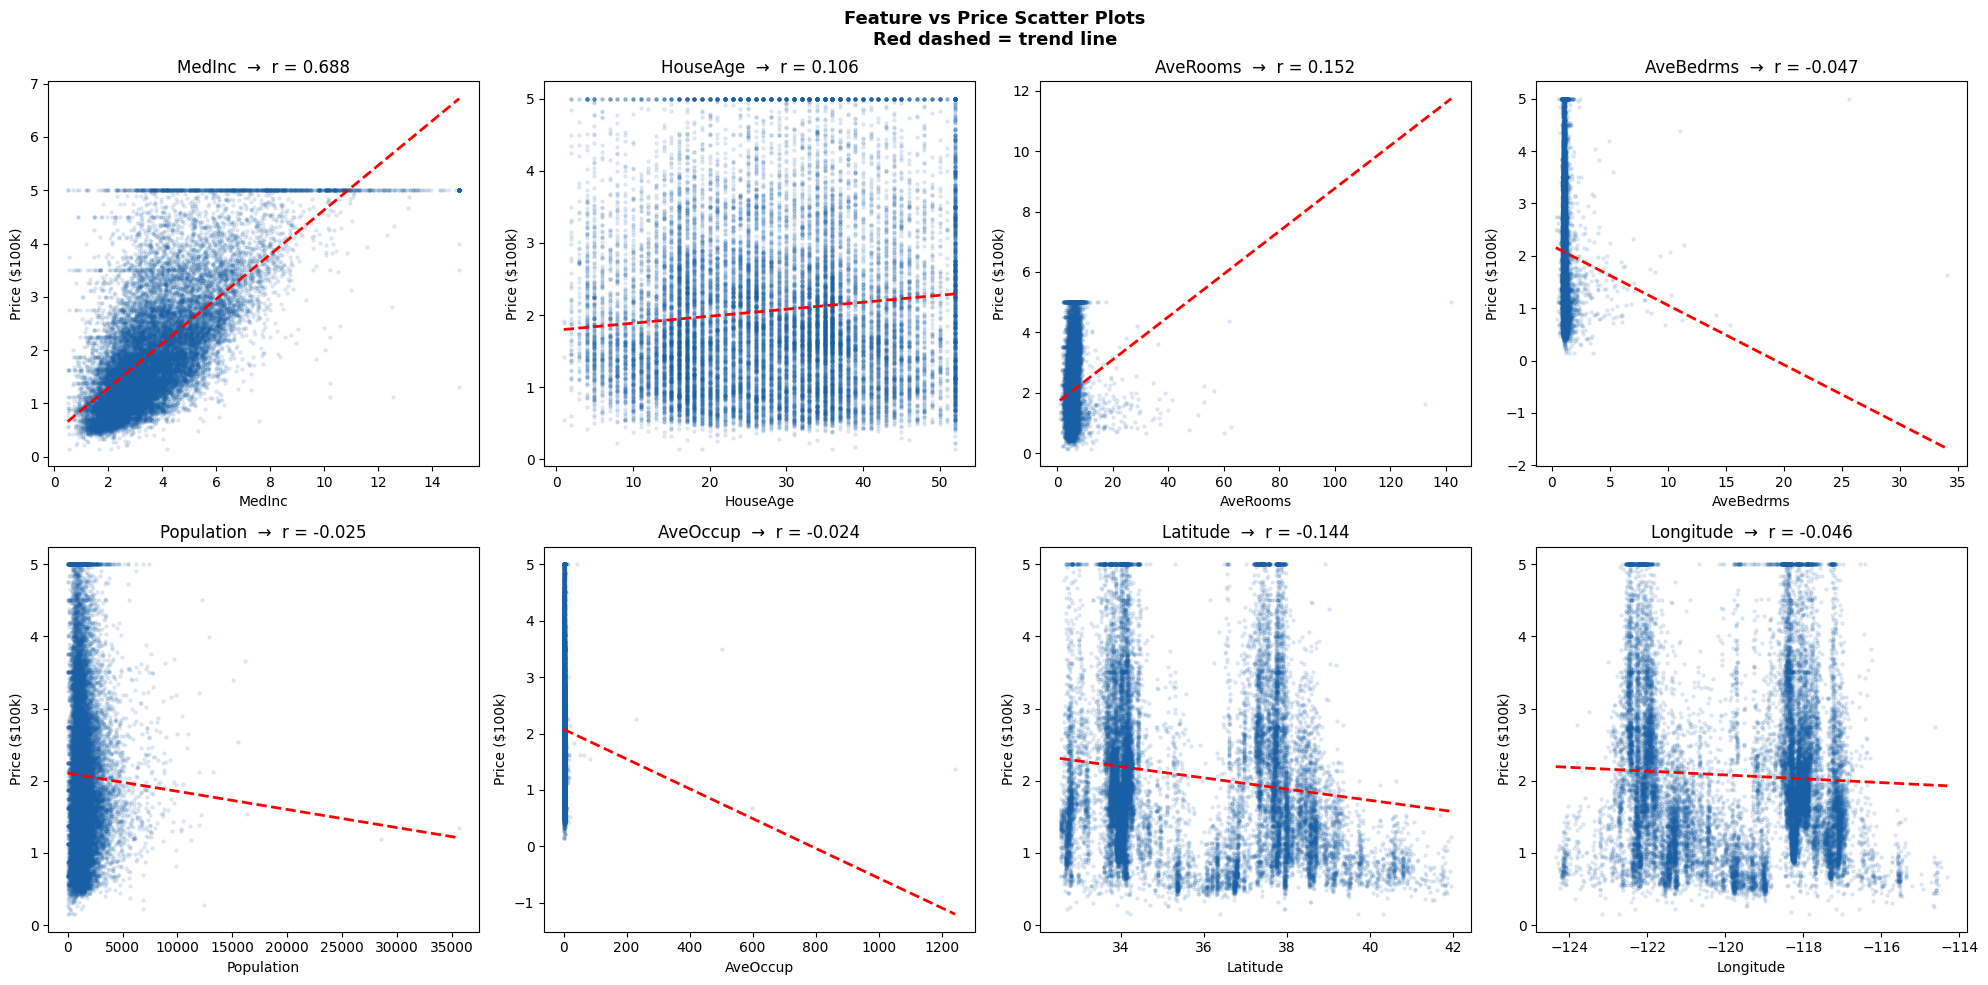

In [96]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
 
features = ['MedInc','HouseAge','AveRooms','AveBedrms',
            'Population','AveOccup','Latitude','Longitude']
 
for i, feat in enumerate(features):
    axes[i].scatter(df[feat], df['price'],
                    alpha=0.1, s=5, color='#185FA5')
 
    # Trend line
    z = np.polyfit(df[feat], df['price'], 1)
    xline = np.linspace(df[feat].min(), df[feat].max(), 100)
    axes[i].plot(xline, np.poly1d(z)(xline),
                 color='red', linewidth=2, linestyle='--')
 
    r = df[feat].corr(df['price'])
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Price ($100k)')
    axes[i].set_title(f'{feat}  →  r = {r:.3f}')
 
plt.suptitle('Feature vs Price Scatter Plots\nRed dashed = trend line',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**MedInc: clear upward trend ← most important feature**

**Population: no clear pattern ← weak feature**

**Latitude/Longitude: Bay Area aur LA expensive dikh rahe hain**

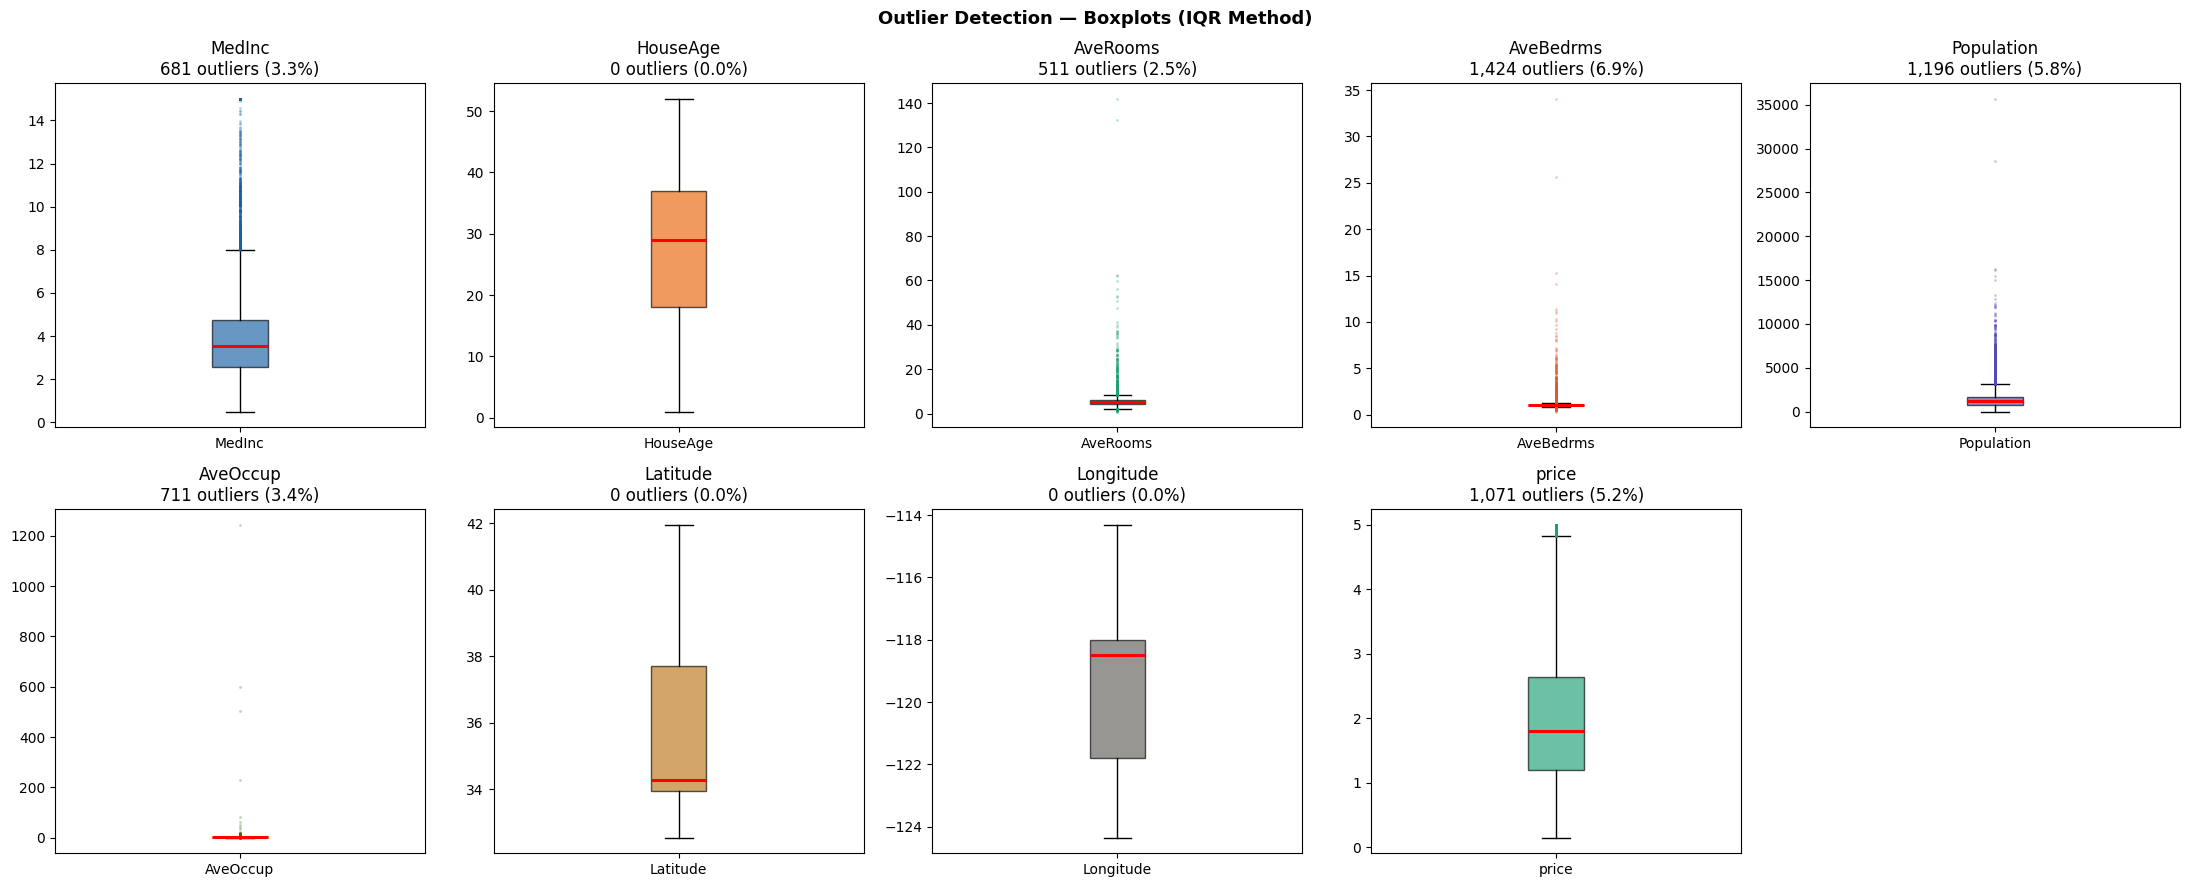

In [145]:
#Outlier Detection (Boxplots)
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()
colors2 = ['#185FA5','#E8640A','#1D9E75','#D85A30','#534AB7',
           '#3B6D11','#BA7517','#5F5E5A','#1D9E75']
 
for i, (col, clr) in enumerate(zip(df.columns, colors2)):
    bp = axes[i].boxplot(
        df[col], patch_artist=True,
        medianprops=dict(color='red', linewidth=2.2),
        flierprops=dict(marker='o', markersize=2,
                        markerfacecolor=clr, alpha=0.3,
                        markeredgewidth=0)
    )
    bp['boxes'][0].set_facecolor(clr)
    bp['boxes'][0].set_alpha(0.65)
 
    # Outlier count calculate karo
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)).sum()
    pct = n_out/len(df)*100
 
    axes[i].set_title(f'{col}\n{n_out:,} outliers ({pct:.1f}%)')
    axes[i].set_xticklabels([col])
 
axes[-1].set_visible(False)
plt.suptitle('Outlier Detection — Boxplots (IQR Method)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [144]:
#Outlier IQR Summary (numbers)
print(f"{'Feature':<15} {'Outliers':>8} {'%':>7}  {'Action'}")
print("-" * 50)
for col in df.columns:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)).sum()
    pct = n_out/len(df)*100
    action = "Cap remove" if pct > 5 else "ok" if pct > 1 else "Clean"
    print(f"{col:<15} {n_out:>8,} {pct:>6.1f}%  {action}")

Feature         Outliers       %  Action
--------------------------------------------------
MedInc               681    3.3%  ok
HouseAge               0    0.0%  Clean
AveRooms             511    2.5%  ok
AveBedrms          1,424    6.9%  Cap remove
Population         1,196    5.8%  Cap remove
AveOccup             711    3.4%  ok
Latitude               0    0.0%  Clean
Longitude              0    0.0%  Clean
price              1,071    5.2%  Cap remove
ROOMS_PER_PERSON      402    1.9%  ok
LOG_POPULATION       848    4.1%  ok
HOUSE_AGE_SQ           0    0.0%  Clean


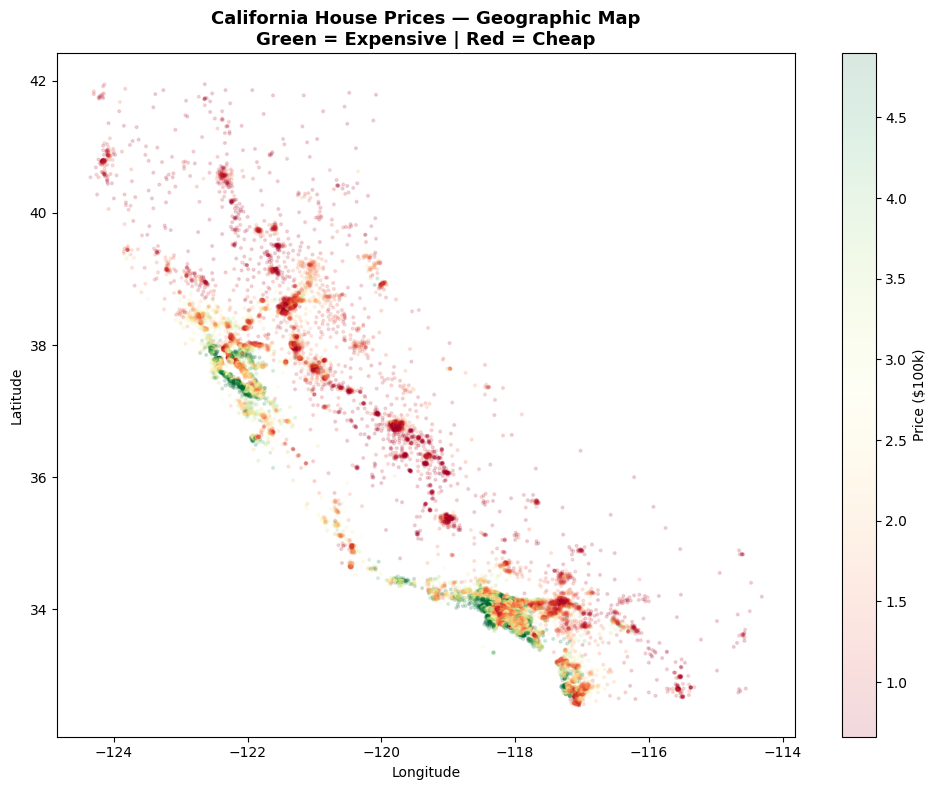

In [143]:
#Geographic Map
plt.figure(figsize=(10, 8))
sc = plt.scatter(
    df['Longitude'], df['Latitude'],
    c=df['price'],           # color = price
    cmap='RdYlGn',           # red=cheap, green=expensive
    alpha=0.15, s=4,
    vmin=df['price'].quantile(0.05),
    vmax=df['price'].quantile(0.95)
)
plt.colorbar(sc, label='Price ($100k)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California House Prices — Geographic Map\nGreen = Expensive | Red = Cheap',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [100]:
feat_importance = df.corr()['price'].drop('price').abs().sort_values(ascending=False)
 
print("Feature Importance (|Correlation| with PRICE):")
print("-" * 55)
for feat, val in feat_importance.items():
    real_corr = df[feat].corr(df['price'])
    direction = "↑ price is huge" if real_corr > 0 else "↓ price is low"
    strength  = "STRONG" if val > 0.3 else "moderate" if val > 0.1 else "weak"
    bar = '█' * int(val * 25)
    print(f"{feat:<15} |r|={val:.3f}  [{strength}]  {direction}")
    print(f"               {bar}")
 
print("\nKONCLUSION:")
print("  1. MedInc    → MOST IMPORTANT — More income = More Expensive")
print("  2. Latitude  → Location matter (Bay Area vs Central Valley)")
print("  3. AveOccup  → Most people in one house = cheap area")
print("  4. HouseAge  → weak — age does not affect on price")

Feature Importance (|Correlation| with PRICE):
-------------------------------------------------------
MedInc          |r|=0.688  [STRONG]  ↑ price is huge
               █████████████████
AveRooms        |r|=0.152  [moderate]  ↑ price is huge
               ███
Latitude        |r|=0.144  [moderate]  ↓ price is low
               ███
HouseAge        |r|=0.106  [moderate]  ↑ price is huge
               ██
AveBedrms       |r|=0.047  [weak]  ↓ price is low
               █
Longitude       |r|=0.046  [weak]  ↓ price is low
               █
Population      |r|=0.025  [weak]  ↓ price is low
               
AveOccup        |r|=0.024  [weak]  ↓ price is low
               

KONCLUSION:
  1. MedInc    → MOST IMPORTANT — More income = More Expensive
  2. Latitude  → Location matter (Bay Area vs Central Valley)
  3. AveOccup  → Most people in one house = cheap area
  4. HouseAge  → weak — age does not affect on price


**Univariate Analysis:**

**Now Start meeting with our individual friends**

In [101]:
df.head(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [102]:
print("Summary of MedInc:")
print("=" * 40)
df['MedInc'].describe()

Summary of MedInc:


count    20640.000000
mean         3.870671
std          1.899822
min          0.499900
25%          2.563400
50%          3.534800
75%          4.743250
max         15.000100
Name: MedInc, dtype: float64

**MedInc**

In [103]:
print("value_counts of top 10 MedInc:")
print("=" * 40)
df['MedInc'].sort_values(ascending=False).value_counts().head(10)

value_counts of top 10 MedInc:


MedInc
15.0001    49
3.1250     49
2.8750     46
4.1250     44
2.6250     44
3.8750     41
3.3750     38
3.0000     38
4.0000     37
3.6250     37
Name: count, dtype: int64

**Interesting some of our friends are very rich.**

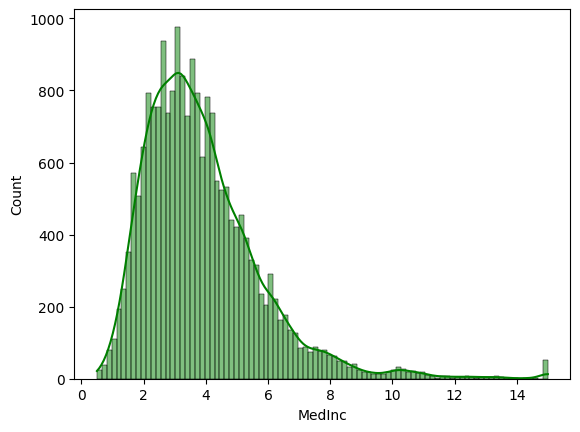

In [104]:
#check the distribution using dist plot
sns.histplot(df["MedInc"], kde=True, color="green")
plt.show()

In [105]:
#now check the skewness and kurtosis of MedInc column
print("Skewness: ", df['MedInc'].skew().round(2))
print("Kurtosis: ", df['MedInc'].kurtosis().round(2))
print("=" * 40)

Skewness:  1.65
Kurtosis:  4.95


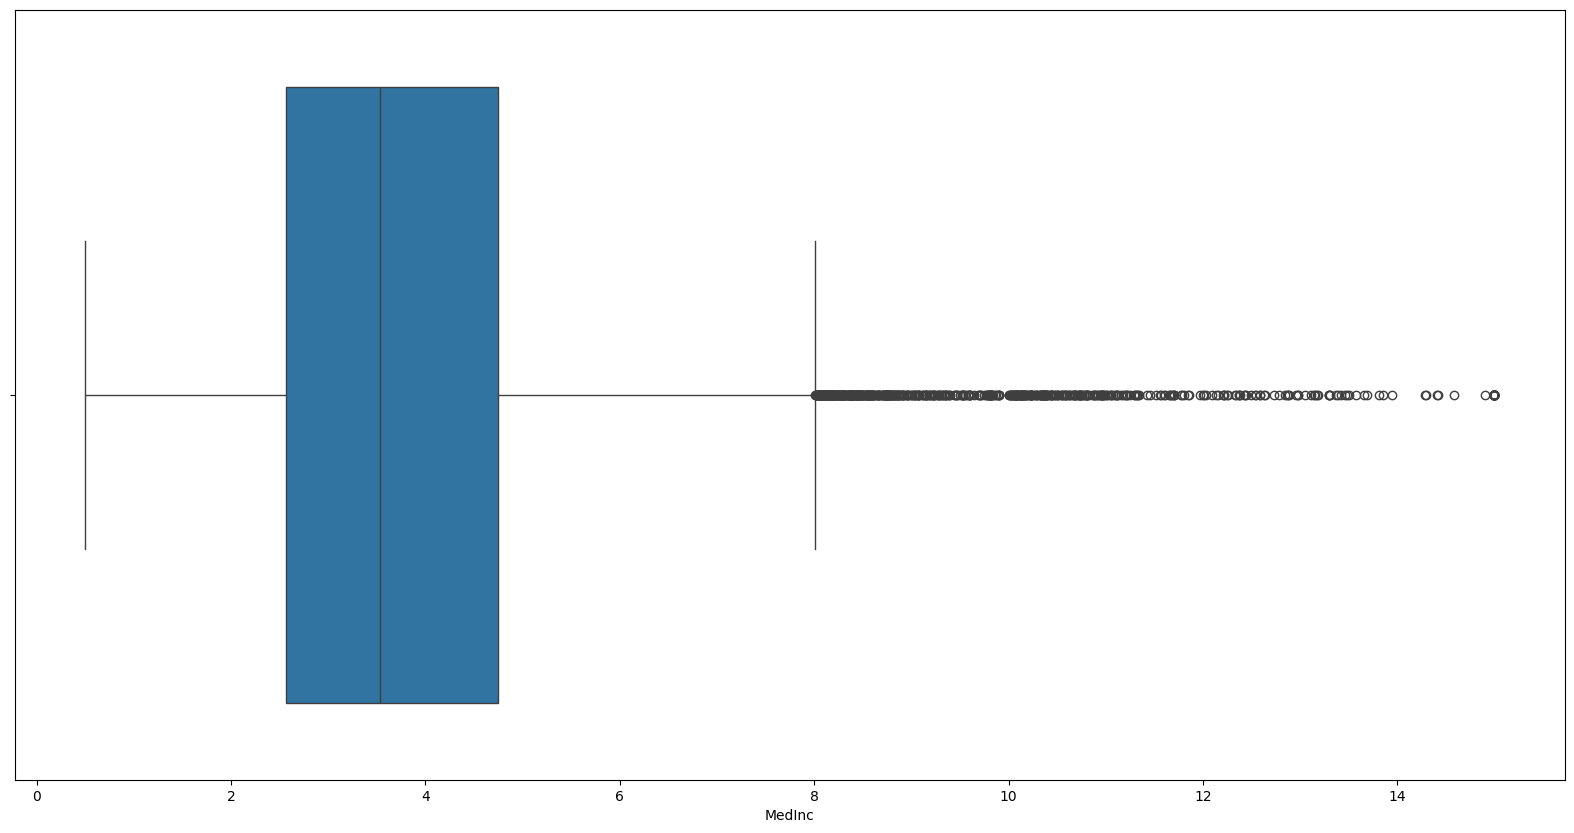

In [106]:
#now check the outliers using Box plot
fig = plt.figure(figsize=(20, 10))
sns.boxplot(data=df['MedInc'], orient="h")
plt.show()

In [107]:
#now check how many people have medinc greter than 8
df[df['MedInc'] > 8].shape

(690, 9)

**HouseAge**

In [108]:
print("Summary of HouseAge:")
print("=" * 40)
df['HouseAge'].describe()

Summary of HouseAge:


count    20640.000000
mean        28.639486
std         12.585558
min          1.000000
25%         18.000000
50%         29.000000
75%         37.000000
max         52.000000
Name: HouseAge, dtype: float64

In [109]:
#now check the skewness and kurtosis
print("Skewness: ", df['HouseAge'].skew().round(2))
print("Kurtosis: ", df['HouseAge'].kurtosis().round(2))
print("=" * 40)

Skewness:  0.06
Kurtosis:  -0.8


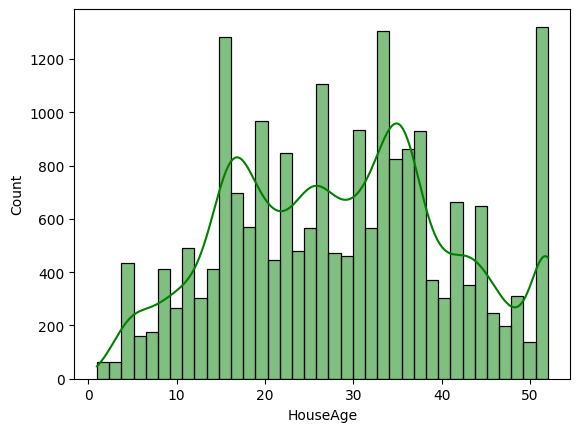

In [110]:
#now check the distribution by using dist plot
sns.histplot(df["HouseAge"], kde=True, color="green")
plt.show()

**AveRooms**

In [111]:
#check the statiscal summary
print("Statistical summary of AveRooms")
print("=" * 40)
df['AveRooms'].describe().round(2)

Statistical summary of AveRooms


count    20640.00
mean         5.43
std          2.47
min          0.85
25%          4.44
50%          5.23
75%          6.05
max        141.91
Name: AveRooms, dtype: float64

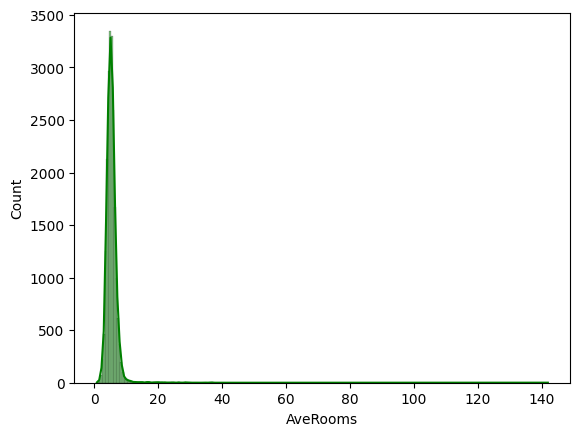

In [112]:
#check the distrubution by using dist plot
sns.histplot(df["AveRooms"], kde=True, color="green")
plt.show()

In [113]:
#now check the skewness and kurtosis
print("Skewness: ", df['AveRooms'].skew().round(2))
print("Kurtosis: ", df['AveRooms'].kurtosis().round(2))
print("=" * 40)

Skewness:  20.7
Kurtosis:  879.35


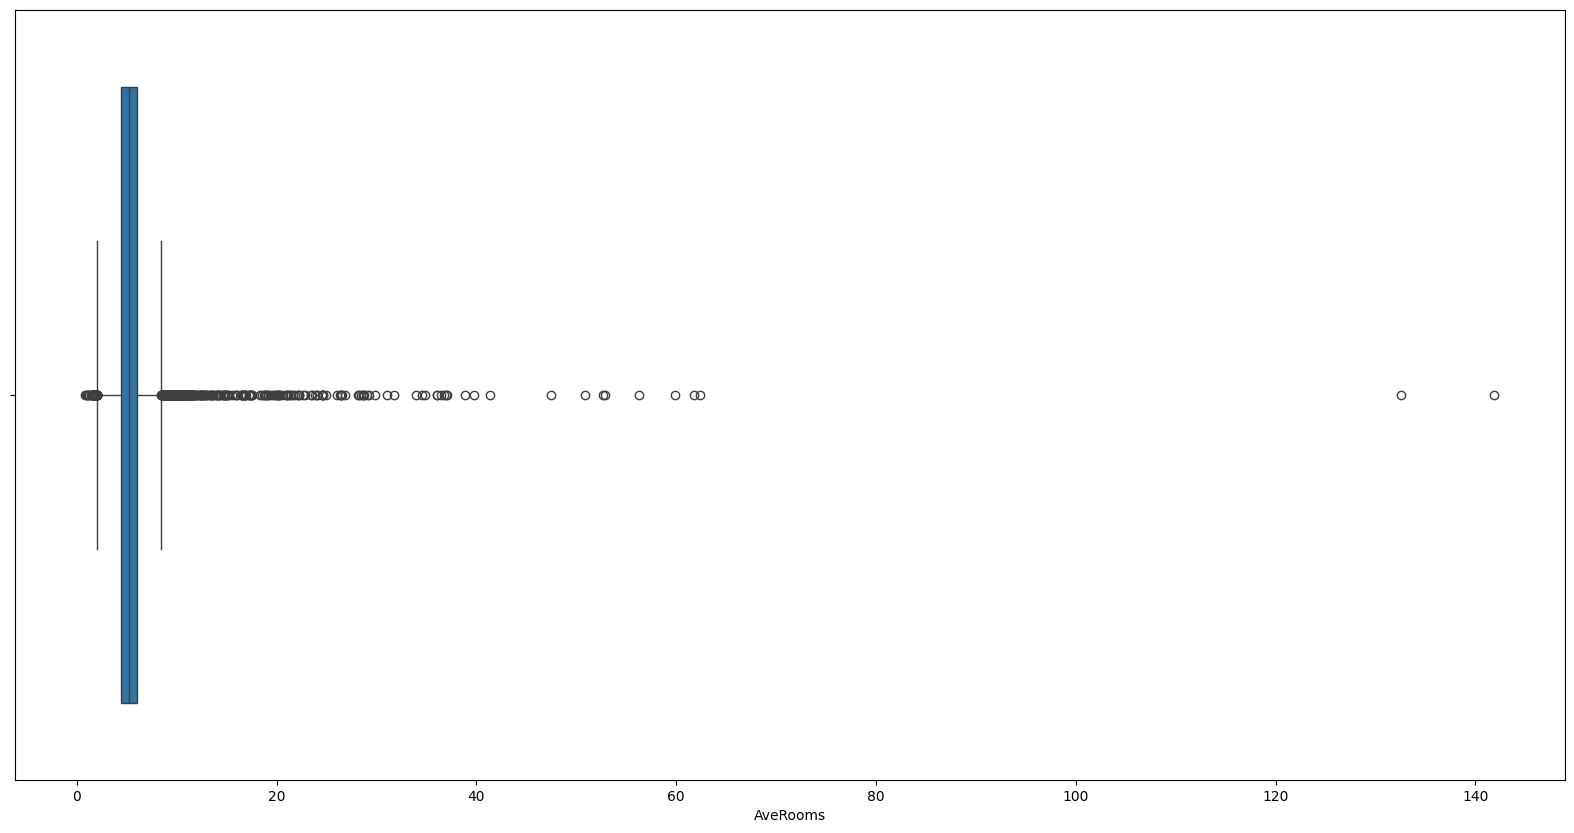

In [114]:
#checking the outliers using Box plot
fig = plt.figure(figsize=(20, 10))
sns.boxplot(data=df['AveRooms'], orient="h")
plt.show()

In [115]:
df[df['AveRooms'] > 10].shape

(226, 9)

In [116]:
df[df['AveRooms'] > 10].head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
1023,2.2417,15.0,10.515306,2.372449,573.0,2.923469,38.72,-119.93,0.979
1024,3.1500,16.0,29.852941,5.323529,202.0,1.980392,38.52,-120.00,1.406
1030,3.0125,15.0,10.168591,2.057737,1103.0,2.547344,38.55,-120.25,1.117
1102,2.4028,17.0,31.777778,9.703704,47.0,1.740741,40.06,-121.54,0.675
1233,3.7500,10.0,16.847534,3.237668,546.0,2.448430,38.23,-120.34,1.214


In [117]:
df['AveRooms'].max()

np.float64(141.9090909090909)

In [118]:
# want to know the value of averoom greater than 15
df['AveRooms'].sort_values(ascending=False).head(10)

1914     141.909091
1979     132.533333
12447     62.422222
1913      61.812500
11862     59.875000
1912      56.269231
9676      52.848214
11707     52.690476
2395      50.837838
1240      47.515152
Name: AveRooms, dtype: float64

In [119]:
df.loc[1914]

MedInc          1.875000
HouseAge       33.000000
AveRooms      141.909091
AveBedrms      25.636364
Population     30.000000
AveOccup        2.727273
Latitude       38.910000
Longitude    -120.100000
price           5.000010
Name: 1914, dtype: float64

In [120]:
#df['AveRooms'] = df['AveRooms'].clip(upper=20)

In [121]:
#df['AveRooms'].max()

In [122]:
#checking the outliers using Box plot
#fig = plt.figure(figsize=(20, 10))
#sns.boxplot(data=df['AveRooms'], orient="h")
#plt.show()

In [123]:
df.head(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [142]:
#Before Engineering — Original Correlations
print("BEFORE Feature Engineering:")
print("-" * 40)
orig_corr = df.corr()['price'].drop('price').abs().sort_values(ascending=False)
for feat, val in orig_corr.items():
    bar = '█' * int(val * 20)
    print(f"  {feat:<15} {val:.3f}  {bar}")

BEFORE Feature Engineering:
----------------------------------------
  MedInc          0.688  █████████████
  ROOMS_PER_PERSON 0.209  ████
  AveRooms        0.152  ███
  Latitude        0.144  ██
  HOUSE_AGE_SQ    0.120  ██
  HouseAge        0.106  ██
  AveBedrms       0.047  
  Longitude       0.046  
  Population      0.025  
  AveOccup        0.024  
  LOG_POPULATION  0.021  


**Feature Engineering**

**we need to create new friends by marriaging existing friends to make our friendship clear**

In [126]:
df['ROOMS_PER_PERSON'] = df['AveRooms'] / df['AveOccup']

In [128]:
df['ROOMS_PER_PERSON'] = df['AveRooms'] / df['AveOccup']
 
# Before/After correlation
r_before = df['AveRooms'].corr(df['price'])
r_after  = df['ROOMS_PER_PERSON'].corr(df['price'])
 
print(f"AveRooms alone     : r = {r_before:.4f}")
print(f"ROOMS_PER_PERSON   : r = {r_after:.4f}")
print(f"\nFirst 5 values:")
print(df[['AveRooms','AveOccup','ROOMS_PER_PERSON','price']].head())

AveRooms alone     : r = 0.1519
ROOMS_PER_PERSON   : r = 0.2095

First 5 values:
   AveRooms  AveOccup  ROOMS_PER_PERSON  price
0  6.984127  2.555556          2.732919  4.526
1  6.238137  2.109842          2.956685  3.585
2  8.288136  2.802260          2.957661  3.521
3  5.817352  2.547945          2.283154  3.413
4  6.281853  2.181467          2.879646  3.422


In [129]:
df['ROOMS_PER_PERSON'].max()

np.float64(55.22222222222222)

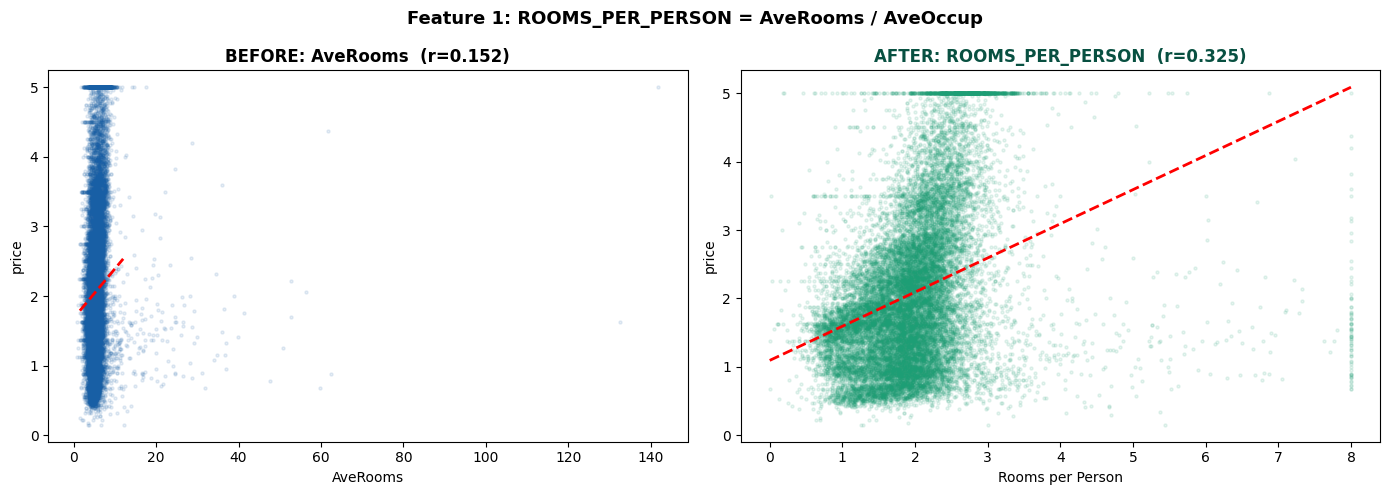

In [ ]:
#ROOMS_PER_PERSON — Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
axes[0].scatter(df['AveRooms'], df['price'], alpha=0.1, s=5, color='#185FA5')
z = np.polyfit(df['AveRooms'], df['price'], 1)
xl = np.linspace(1.5, 12, 200)
axes[0].plot(xl, np.poly1d(z)(xl), 'r--', lw=2)
axes[0].set_title(f'BEFORE: AveRooms  (r={r_before:.3f})', fontweight='bold')
axes[0].set_xlabel('AveRooms'); axes[0].set_ylabel('price')
 
rpp = df['ROOMS_PER_PERSON'].clip(0, 8)
axes[1].scatter(rpp, df['price'], alpha=0.1, s=5, color='#1D9E75')
z2 = np.polyfit(rpp, df['price'], 1)
xl2 = np.linspace(0, 8, 200)
axes[1].plot(xl2, np.poly1d(z2)(xl2), 'r--', lw=2)
axes[1].set_title(f'AFTER: ROOMS_PER_PERSON  (r={rpp.corr(df["price"]):.3f})',
                  fontweight='bold', color='#085041')
axes[1].set_xlabel('Rooms per Person'); axes[1].set_ylabel('price')
 
plt.suptitle('Feature 1: ROOMS_PER_PERSON = AveRooms / AveOccup',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**As we see before our population column is heavily right skewed so we need to normalize it**

In [132]:
df['LOG_POPULATION'] = np.log1p(df['Population'])
 
skew_before = df['Population'].skew()
skew_after  = df['LOG_POPULATION'].skew()
 
print(f"Population skewness BEFORE : {skew_before:.2f}  (bad!)")
print(f"Population skewness AFTER  : {skew_after:.2f}  (near-normal)")

Population skewness BEFORE : 4.94  (bad!)
Population skewness AFTER  : -1.04  (near-normal)


In [133]:
print(f"\nExample values:")
examples = [100, 500, 1000, 5000, 10000, 35000]
for x in examples:
    print(f"  Population={x:>6,}  →  log1p = {np.log1p(x):.3f}")



Example values:
  Population=   100  →  log1p = 4.615
  Population=   500  →  log1p = 6.217
  Population= 1,000  →  log1p = 6.909
  Population= 5,000  →  log1p = 8.517
  Population=10,000  →  log1p = 9.210
  Population=35,000  →  log1p = 10.463


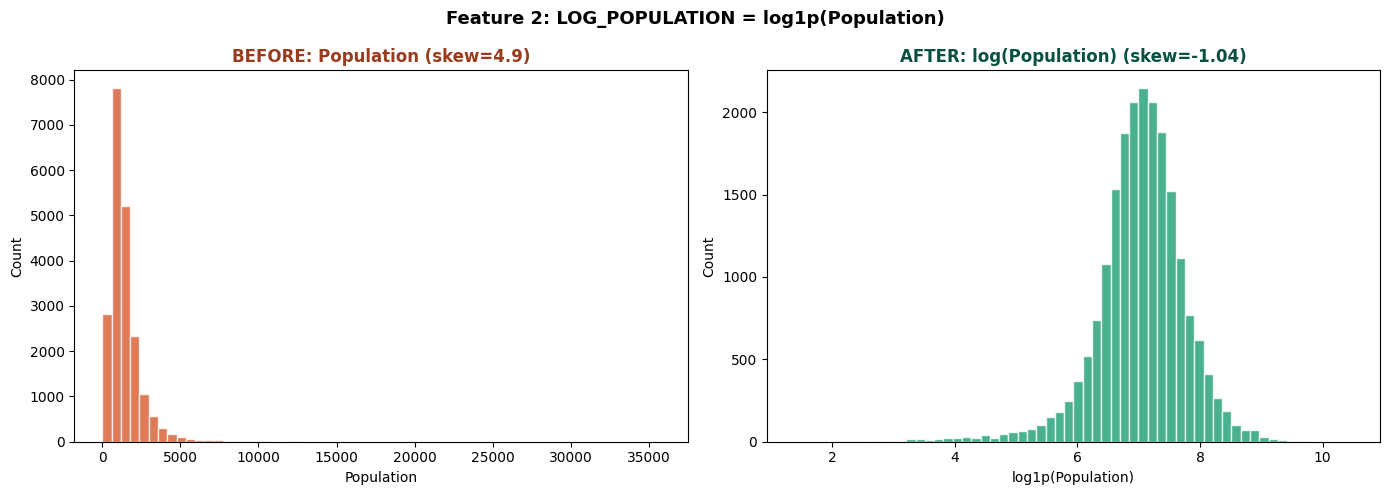

In [141]:
#LOG Transform — Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
axes[0].hist(df['Population'], bins=60, color='#D85A30', alpha=0.8, edgecolor='white')
axes[0].set_title(f'BEFORE: Population (skew={skew_before:.1f})',
                  fontweight='bold', color='#993C1D')
axes[0].set_xlabel('Population'); axes[0].set_ylabel('Count')
 
axes[1].hist(df['LOG_POPULATION'], bins=60, color='#1D9E75', alpha=0.8, edgecolor='white')
axes[1].set_title(f'AFTER: log(Population) (skew={skew_after:.2f})',
                  fontweight='bold', color='#085041')
axes[1].set_xlabel('log1p(Population)'); axes[1].set_ylabel('Count')
 
plt.suptitle('Feature 2: LOG_POPULATION = log1p(Population)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [136]:
df['HOUSE_AGE_SQ'] = df['HouseAge'] ** 2
 
r_age    = df['HouseAge'].corr(df['price'])
r_age_sq = df['HOUSE_AGE_SQ'].corr(df['price'])
 
print(f"HouseAge    r = {r_age:.4f}")
print(f"HouseAge²   r = {r_age_sq:.4f}")
print(f"\nFirst 5 values:")
print(df[['HouseAge','HOUSE_AGE_SQ','price']].head())

HouseAge    r = 0.1056
HouseAge²   r = 0.1200

First 5 values:
   HouseAge  HOUSE_AGE_SQ  price
0      41.0        1681.0  4.526
1      21.0         441.0  3.585
2      52.0        2704.0  3.521
3      52.0        2704.0  3.413
4      52.0        2704.0  3.422


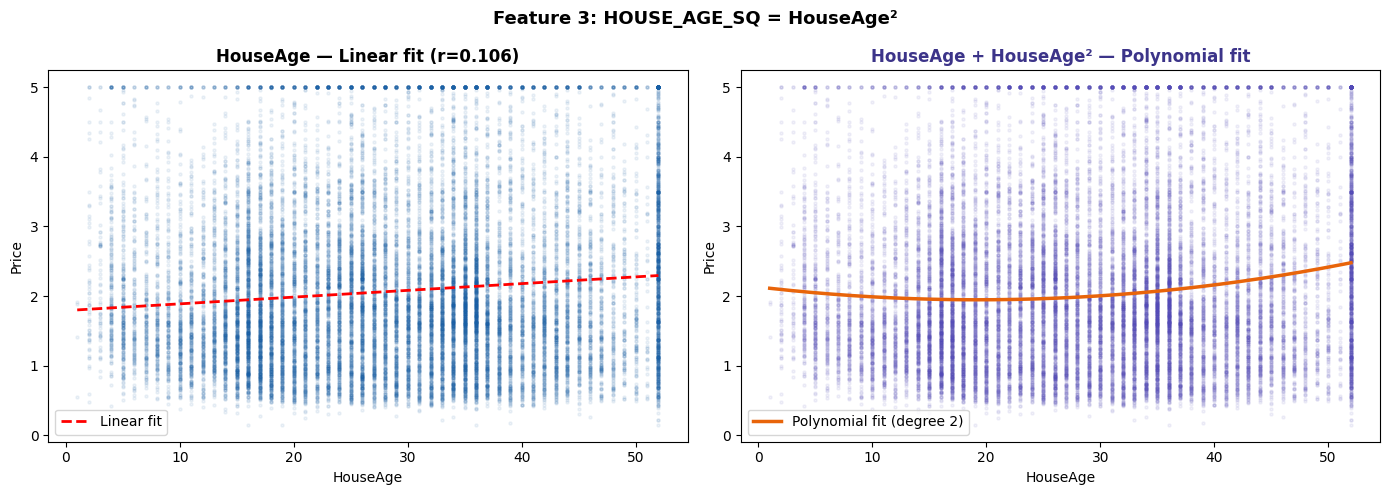

In [140]:
#Polynomial — Plot ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Linear fit
axes[0].scatter(df['HouseAge'], df['price'], alpha=0.07, s=5, color='#185FA5')
z = np.polyfit(df['HouseAge'], df['price'], 1)
xl = np.linspace(1, 52, 200)
axes[0].plot(xl, np.poly1d(z)(xl), 'r--', lw=2, label='Linear fit')
axes[0].set_title(f'HouseAge — Linear fit (r={r_age:.3f})', fontweight='bold')
axes[0].set_xlabel('HouseAge'); axes[0].set_ylabel('Price')
axes[0].legend()
 
# Polynomial fit
axes[1].scatter(df['HouseAge'], df['price'], alpha=0.07, s=5, color='#534AB7')
z2 = np.polyfit(df['HouseAge'], df['price'], 2)
axes[1].plot(xl, np.poly1d(z2)(xl), color='#E8640A', lw=2.5,
             label='Polynomial fit (degree 2)')
axes[1].set_title(f'HouseAge + HouseAge² — Polynomial fit',
                  fontweight='bold', color='#3C3489')
axes[1].set_xlabel('HouseAge'); axes[1].set_ylabel('Price')
axes[1].legend()
 
plt.suptitle('Feature 3: HOUSE_AGE_SQ = HouseAge²',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
 

In [ ]:
df['INCOME_x_ROOMS'] = df['MedInc'] * df['AveRooms']
 
r_inc   = df['MedInc'].corr(df['price'])
r_rooms = df['AveRooms'].corr(df['price'])
r_inter = df['INCOME_x_ROOMS'].clip(0,80).corr(df['price'])
 
print(f"MedInc alone        r = {r_inc:.4f}")
print(f"AveRooms alone      r = {r_rooms:.4f}")
print(f"MedInc × AveRooms   r = {r_inter:.4f}  ← STRONGEST!")